In [ ]:
# losss function
# to find the loss function for a given model
# loss function  = (predicted - actual)^2



# building a linear regresssion model from scratch


# Linear regression

 Y  = WX + B



linear regression 

Y = W*x + B

y: Predicted value


x: Input (feature)


w: Weight (slope)


b: Bias/intercept

#Gradient Descent
Gradient Descent is an optimization algorithm used to minimize a cost/loss function by iteratively moving in the direction of the steepest descent (negative gradient).

w:=w−η⋅ 
∂w
∂L
​
 ,b:=b−η⋅ 
∂b
∂L
​


In [39]:
import numpy as np

class LinearRegression:
    def __init__(self,  learning_rate, n_iterations):
        
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, x,y):
        
        # no of features(n) and no of samples(m)
        self.m, self.n  = x.shape

        # initializing weights and bias
        self.weights = np.zeros(self.n)
        self.bias  = 0

        self.x = x
        self.y = y

        for i in range(self.n_iterations):
            self.update_weights()




    
    def update_weights(self):
        y_prediction = self.predict(self.x)

        # calculating gradients
        dw = (-2/self.m) * np.dot(self.x.T,(self.y - y_prediction))

        db = (-2/self.m) * np.sum(self.y - y_prediction)

        # updating the weights and bias

        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

    


    def predict(self, x):
        
        return np.dot(x,self.weights) + self.bias



Work flow of the linear regression model

1. set the learing rate and number of iterations, also initaite weights and bias 

2. build the linear regresion

3. find the Y value for given x value for the corresponding weights bias

4. check the loss fumctionn for these paramenter values

5. update the parameter valeus using a gradient decent 


6. repeat the 3,4,5,are repeated till we get minimum loss function

In [2]:
# importing lib
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# data preprocessing

In [3]:
# load dataset

salary = pd.read_csv('D:\ML-DL-learns\SK-learn\datasets\salary_data.csv')

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16628\3340431152.py:3: SyntaxWarning: invalid escape sequence '\M'
  salary = pd.read_csv('D:\ML-DL-learns\SK-learn\datasets\salary_data.csv')


In [4]:
salary.head()
salary.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

## splitting the data 


In [28]:
x = salary.iloc[:,:-1].values
y = salary.iloc[:,1].values
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)




## trainnig the linear model

In [40]:
linear = LinearRegression(learning_rate=0.01, n_iterations=1000)
# fitting the model
linear.fit(x_train, y_train)





In [44]:
# printing the final bias and the weights
print("weight  :", linear.weights[0])
print("bias    :", linear.bias)

# predicting the values
predicted_value = linear.predict(x_test)

# printing the actual values
print("actual values :", y_test)

# printing the predicted values
print("predicted values :", predicted_value)


weight  : 9634.78529190999
bias    : 23935.49212114018
actual values : [46205 39343 61111 57189 98273 93940]
predicted values : [36460.71300062 34533.75594224 67292.02593474 59584.19770121
 92342.4676937  81744.2038726 ]


Text(0.5, 0, 'Years of Experience')

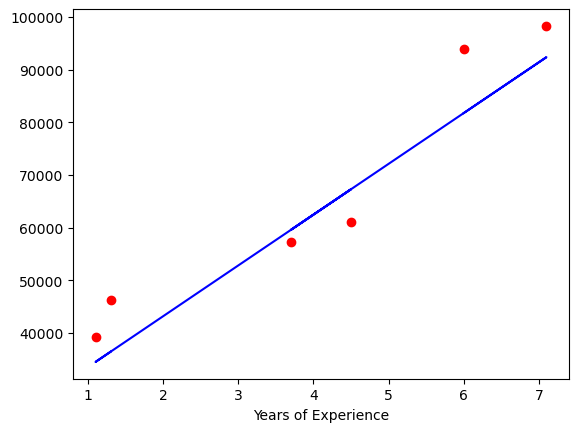

In [48]:
plt.scatter(x_test, y_test, color='red', label='Actual')
plt.plot(x_test, predicted_value, color='blue', label='Predicted')
plt.xlabel('Years of Experience')